# Previsão de Churn de Clientes no Setor de Telecomunicações

## MBA em Data Science e Analytics – USP/Esalq  
**Aluno:** Alisson Felipe Brandão da Silva  

Este notebook tem como objetivo desenvolver, de forma estruturada e reprodutível, um modelo de Aprendizado de Máquina para a previsão de churn de clientes, utilizando um conjunto de dados público do setor de telecomunicações.  

As etapas contemplam a análise exploratória dos dados, o pré-processamento, a modelagem preditiva e a avaliação inicial dos resultados, em conformidade com a metodologia proposta no Trabalho de Conclusão de Curso.


## Carregamento dos Dados

Nesta etapa, realiza-se a leitura do conjunto de dados Telco Customer Churn, que será utilizado ao longo de todo o estudo para a análise e modelagem preditiva.

In [2]:
# ================================
# Bibliotecas de manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Pré-processamento
# ================================
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ================================
# Métricas de avaliação
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    make_scorer
)

In [3]:
# Leitura do dataset a partir do arquivo CSV
dados = pd.read_csv("C:\\Users\\aliss\\OneDrive\\Área de Trabalho\\Faculdade\\MBA Data Sciencee Analytics USP\\TCC\\Jupyter Notebook\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Visualização das primeiras linhas do dataset
dados.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Visão Geral do Conjunto de Dados

Nesta etapa, busca-se compreender a estrutura do dataset, tipos de variáveis e possíveis inconsistências iniciais.

In [4]:
# Informações gerais sobre o dataset
dados.info()

# Estatísticas descritivas das variáveis numéricas
dados.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Limpeza e Pré-processamento dos Dados

Nesta etapa são realizadas correções de inconsistências, tratamento de valores ausentes e adequação dos tipos de dados, garantindo que o conjunto esteja apto para a aplicação dos modelos de Aprendizado de Máquina.


In [5]:
# Verificação de valores ausentes por variável
dados.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
dados.dtypes

# Identificar valores vazios disfarçados
dados["TotalCharges"].value_counts().head(10)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: count, dtype: int64

Embora não tenham sido identificados valores nulos explícitos, foram encontradas inconsistências na variável TotalCharges, armazenada como texto e contendo registros vazios, exigindo tratamento adicional

In [7]:
# Conversão de TotalCharges para numérico (valores inválidos viram NaN)
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")

# Verificação de valores ausentes após conversão
dados.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Tratamento da variável TotalCharges

Apesar de não serem identificados valores nulos explícitos inicialmente, observou-se que a variável *TotalCharges* apresentava registros vazios, armazenados como texto. Dessa forma, foi realizada a conversão para formato numérico, resultando na identificação de valores ausentes, os quais foram tratados por meio da remoção dos registros correspondentes.

In [8]:
# Remoção de linhas com valores ausentes em TotalCharges
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")

dados = dados.dropna()


In [9]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [10]:
dados.Churn.value_counts("Yes")

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

### Preparação da Variável Alvo

Nesta etapa, a variável *Churn* foi transformada em formato binário, possibilitando sua utilização em modelos de classificação supervisionada.

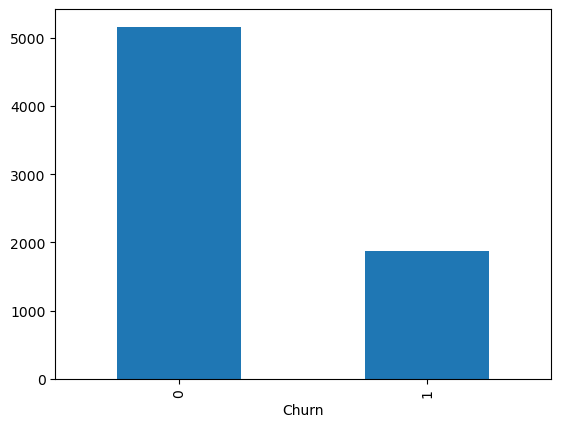

In [11]:
# Conversão da variável Churn para valores binários
dados["Churn"] = dados["Churn"].map({"Yes": 1, "No": 0})

# Distribuição da variável alvo
dados["Churn"].value_counts(normalize=True)

dados["Churn"].value_counts().plot(kind="bar")

# Ajustando os rótulos para horizontal
plt.show()


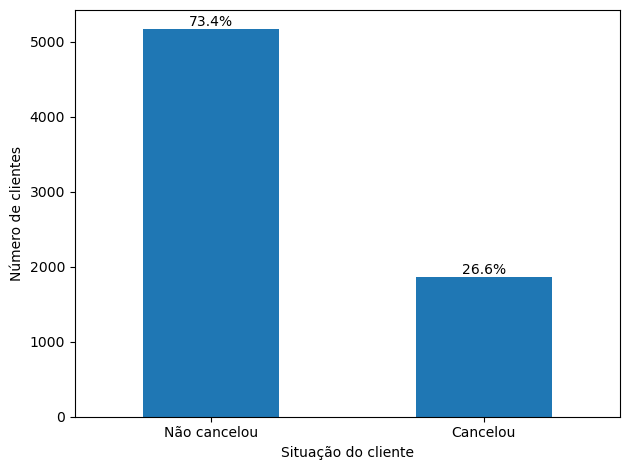

In [12]:
# Contagem absoluta e percentual
contagem = dados["Churn"].value_counts()
percentual = dados["Churn"].value_counts(normalize=True) * 100

# Gráfico
ax = contagem.plot(kind="bar")

# Títulos e rótulos
ax.set_xlabel("Situação do cliente")
ax.set_ylabel("Número de clientes")
ax.set_xticklabels(["Não cancelou", "Cancelou"], rotation=0)

# Inserção dos percentuais acima das barras
for i, v in enumerate(contagem):
    ax.text(
        i,
        v,
        f"{percentual.iloc[i]:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Proporção de churn por tipo de contrato

O gráfico apresenta a distribuição proporcional da variável churn em função do tipo de contrato.

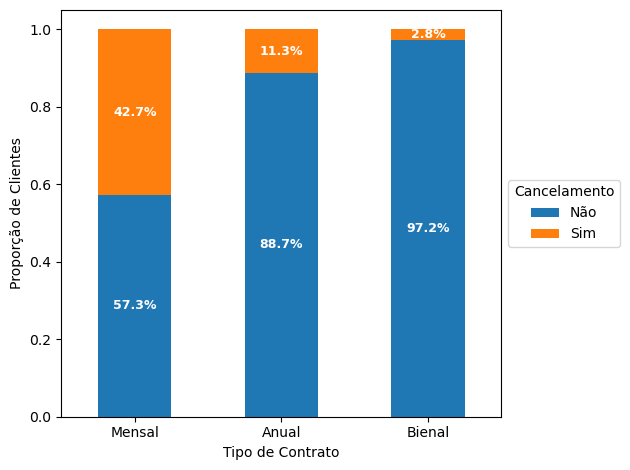

In [13]:
# Renomeando categorias do contrato
dados["Contract"] = dados["Contract"].replace({
    "Month-to-month": "Mensal",
    "One year": "Anual",
    "Two year": "Bienal"
})

# Ordem correta dos contratos
ordem_contratos = ["Mensal", "Anual", "Bienal"]

# Tabela cruzada com ordem definida
ct = pd.crosstab(
    dados["Contract"],
    dados["Churn"],
    normalize="index"
).reindex(ordem_contratos)

ax = ct.plot(kind="bar", stacked=True)

# Ajustando os rótulos para horizontal
ax.set_xticklabels(ct.index, rotation=0)

# Labels dos eixos
ax.set_xlabel("Tipo de Contrato")
ax.set_ylabel("Proporção de Clientes")


# Legenda em português
ax.legend(
    title="Cancelamento",
    bbox_to_anchor=(1, 0.5),
    labels=["Não", "Sim"],
    loc="center left"
)

# Percentuais em branco e negrito
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.1f}%" for v in container.datavalues],
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Tempo de permanência (tenure) por status de churn

A variável tenure representa o tempo de permanência do cliente em meses. A análise compara o tempo médio de permanência entre clientes que cancelaram e os que permaneceram ativos.

In [14]:
dados.groupby("Churn")["tenure"].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

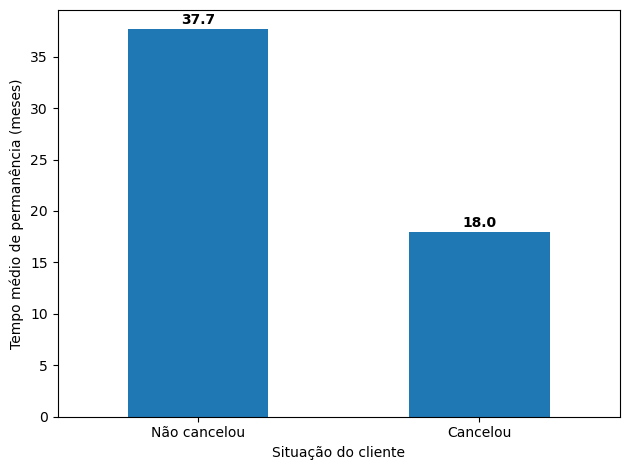

In [15]:
# Cálculo da média do tempo de permanência por status de cancelamento
media_tempo = dados.groupby("Churn")["tenure"].mean()

# Renomeando categorias do eixo X
media_tempo.index = ["Não cancelou", "Cancelou"]

# Gráfico
ax = media_tempo.plot(kind="bar")
ax.set_xticklabels(media_tempo.index, rotation=0)
plt.xlabel("Situação do cliente")
plt.ylabel("Tempo médio de permanência (meses)")

plt.tight_layout()

# Inserindo valores acima das barras
for i, v in enumerate(media_tempo.values):
    ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontweight="bold")

plt.show()

### Valor médio da mensalidade (MonthlyCharges) por status de churn

A análise compara o valor médio da mensalidade entre clientes que cancelaram e os que permaneceram ativos.

In [16]:
dados.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

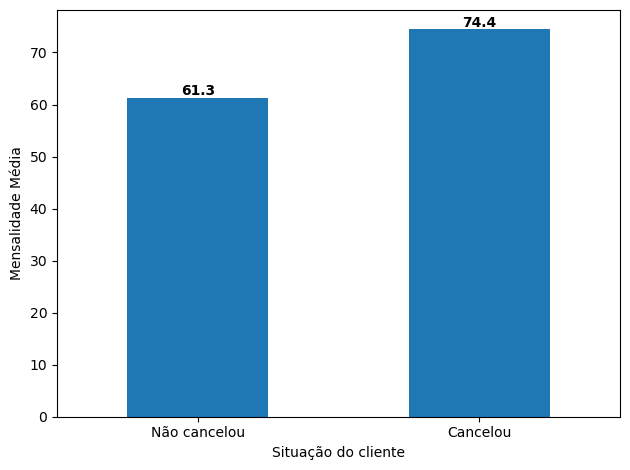

In [17]:
# Cálculo da média da mensalidade por status de cancelamento
mensalidade = dados.groupby("Churn")["MonthlyCharges"].mean()

# Renomeando categorias do eixo X
mensalidade.index = ["Não cancelou", "Cancelou"]

# Gráfico
ax = mensalidade.plot(kind="bar")

ax.set_xticklabels(mensalidade.index, rotation=0)
plt.xlabel("Situação do cliente")
plt.ylabel("Mensalidade Média")

plt.tight_layout()

# Inserindo valores acima das barras
for i, v in enumerate(mensalidade.values):
    ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontweight="bold")
    
plt.show()


## Preparação dos Dados para Modelagem

Após a etapa de análise exploratória e identificação dos principais fatores associados ao churn, os dados foram preparados para a aplicação de modelos preditivos. Essa etapa incluiu a separação da variável alvo, o tratamento das variáveis categóricas e numéricas e a divisão do conjunto de dados em bases de treinamento e teste.

### Separação da variável alvo

A variável *Churn* foi definida como variável alvo do modelo, enquanto as demais variáveis foram utilizadas como preditoras. A variável identificadora *customerID* foi removida por não possuir valor preditivo.

In [18]:
# Variável alvo
y = dados["Churn"]

# Variáveis explicativas
X = dados.drop(columns=["Churn", "customerID"])

### Identificação das variáveis categóricas e numéricas

As variáveis foram classificadas em categóricas e numéricas para aplicação de técnicas de pré-processamento adequadas a cada tipo.

In [19]:
# Variáveis categóricas
cat_cols = X.select_dtypes(include="object").columns

# Variáveis numéricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols, num_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

### Codificação das variáveis categóricas

As variáveis categóricas foram transformadas por meio da técnica de *One-Hot Encoding*, permitindo sua utilização em modelos de aprendizado de máquina.

In [20]:
encoder = OneHotEncoder(drop="first", sparse_output=False)

X_cat = encoder.fit_transform(X[cat_cols])

X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

### Padronização das variáveis numéricas

As variáveis numéricas foram padronizadas para garantir que estivessem na mesma escala, facilitando a convergência e a interpretação dos modelos.

In [21]:
scaler = StandardScaler()

X_num = scaler.fit_transform(X[num_cols])

X_num = pd.DataFrame(X_num, columns=num_cols)

### Consolidação da base de dados

Após o pré-processamento, as variáveis numéricas e categóricas foram combinadas, resultando no conjunto final de dados utilizado na etapa de modelagem.

In [22]:
X_prepared = pd.concat(
    [X_num.reset_index(drop=True),
     X_cat.reset_index(drop=True)],
    axis=1
)

X_prepared.shape

(7032, 30)

### Divisão dos dados em treino e teste

O conjunto de dados foi dividido em bases de treinamento e teste, preservando a proporção da variável alvo por meio da técnica de estratificação.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [24]:
X_train.shape
y_train.value_counts(normalize=True)

Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

## Modelo Baseline

Com o objetivo de estabelecer uma referência inicial de desempenho, foi treinado um modelo baseline de classificação. Esse modelo permite avaliar se abordagens mais complexas são justificadas nas etapas posteriores do trabalho.

Foi utilizada a Regressão Logística como modelo baseline por sua simplicidade, interpretabilidade e ampla utilização em problemas de classificação binária, especialmente em análises de churn.

In [ ]:
# Instanciando o modelo baseline
modelo_baseline = LogisticRegression(random_state=42)

# Treinando o modelo
modelo_baseline.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
# Predições
y_pred_lr = modelo_baseline.predict(X_test)

### Avaliação do desempenho

O desempenho do modelo foi avaliado por meio de métricas adequadas para problemas com desbalanceamento moderado, incluindo acurácia, precisão, recall e F1-score.

In [27]:
# Acurácia
accuracy = accuracy_score(y_test, y_pred_lr)

accuracy

0.8061611374407583

In [28]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



### Matriz de confusão

A matriz de confusão foi utilizada para analisar a distribuição dos acertos e erros do modelo, permitindo melhor compreensão do comportamento das predições.

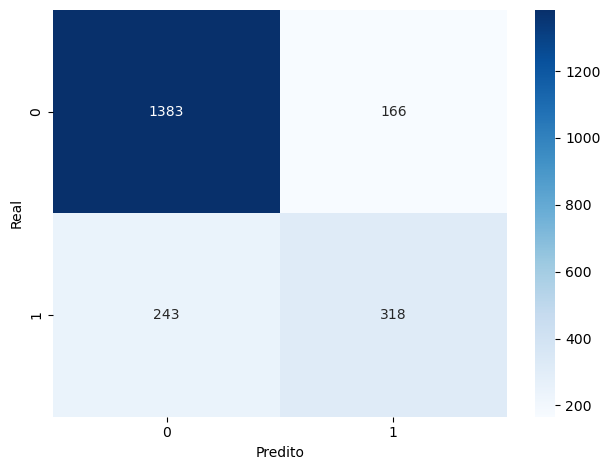

In [29]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()

plt.show()

### Validação Cruzada – Regressão Logística (Stratified K-Fold)

In [30]:
# Definição do modelo (o mesmo que você já usou)
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas focadas na classe churn (classe 1)
scoring = {
    'accuracy': 'accuracy',
    'precision_churn': make_scorer(precision_score, pos_label=1),
    'recall_churn': make_scorer(recall_score, pos_label=1),
    'f1_churn': make_scorer(f1_score, pos_label=1)
}

# Validação cruzada
cv_results = cross_validate(
    logistic_model,
    X_prepared,
    y,
    cv=skf,
    scoring=scoring
)

# Resultado médio
cv_summary = pd.DataFrame(cv_results).mean()
print(cv_summary)

fit_time                0.020950
score_time              0.009517
test_accuracy           0.804607
test_precision_churn    0.657742
test_recall_churn       0.552697
test_f1_churn           0.600623
dtype: float64


### Modelo Random Forest

Como etapa seguinte da análise, foi implementado um modelo baseado em árvores de decisão utilizando o algoritmo Random Forest. Esse método combina múltiplas árvores de decisão construídas a partir de subconjuntos aleatórios dos dados, reduzindo a variância e aumentando a capacidade de generalização do modelo (Géron, 2019).

In [31]:
# Treinamento do modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [32]:
# Predições do modelo Random Forest
y_pred_rf = rf_model.predict(X_test)

In [33]:
# Avaliação do modelo Random Forest
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.63      0.47      0.54       561

    accuracy                           0.78      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



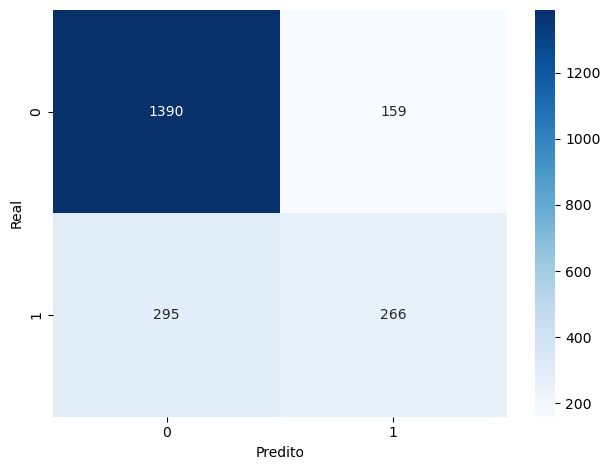

In [34]:
# Matriz de confusão para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()

plt.show()

In [35]:
# Validação cruzada para Random Forest
cv_results_rf = cross_validate(
    rf_model,
    X_prepared,
    y,
    cv=skf,
    scoring=scoring
)
cv_summary_rf = pd.DataFrame(cv_results_rf).mean()
print(cv_summary_rf)

fit_time                1.318933
score_time              0.048124
test_accuracy           0.792093
test_precision_churn    0.640578
test_recall_churn       0.498129
test_f1_churn           0.560259
dtype: float64


### Ajustando o desbalanceamento

In [36]:
# Ajustando o desbalanceamento
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf_balanced.fit(X_train, y_train)
y_pred_rf_balanced = rf_balanced.predict(X_test)
print(classification_report(y_test, y_pred_rf_balanced))


              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1549
           1       0.61      0.46      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.69      2110
weighted avg       0.77      0.78      0.77      2110



### Gradient Boosting

Modelos de boosting costumam capturar melhor padrões complexos.
Segundo Géron (2019), métodos de boosting frequentemente superam Random Forest em tarefas de classificação estruturada.

In [37]:
### Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.51      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.78      0.79      0.79      2110



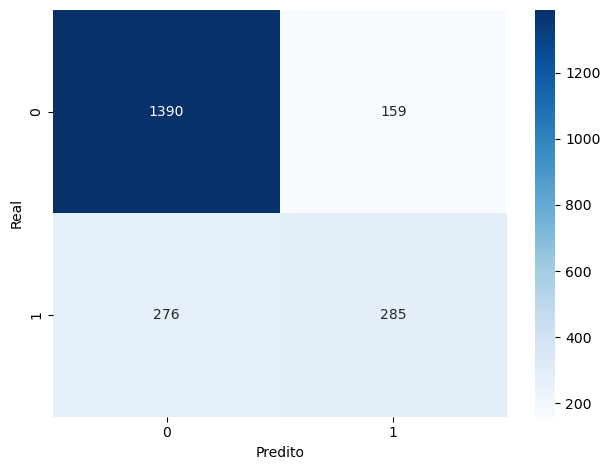

In [38]:
# Matriz de confusão Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()

plt.show()

In [39]:
# Validação cruzada para Gradient Boosting
cv_results_gb = cross_validate(
    gb_model,
    X_prepared,
    y,
    cv=skf,
    scoring=scoring
)
cv_summary_gb = pd.DataFrame(cv_results_gb).mean()
print(cv_summary_gb)

fit_time                1.596012
score_time              0.011512
test_accuracy           0.803895
test_precision_churn    0.667730
test_recall_churn       0.522737
test_f1_churn           0.586344
dtype: float64


In [40]:
# Importancia das variáveis
feature_importances = pd.Series(
    gb_model.feature_importances_,
    index=X_prepared.columns
).sort_values(ascending=False)

feature_importances.head(15)

Contract_Mensal                         0.399456
tenure                                  0.153349
InternetService_Fiber optic             0.100479
TotalCharges                            0.085263
MonthlyCharges                          0.077625
PaymentMethod_Electronic check          0.047991
OnlineSecurity_Yes                      0.018723
PaperlessBilling_Yes                    0.015216
TechSupport_Yes                         0.013865
Contract_Bienal                         0.012014
MultipleLines_Yes                       0.009085
DeviceProtection_No internet service    0.008344
StreamingTV_No internet service         0.008055
SeniorCitizen                           0.006994
StreamingMovies_Yes                     0.005488
dtype: float64

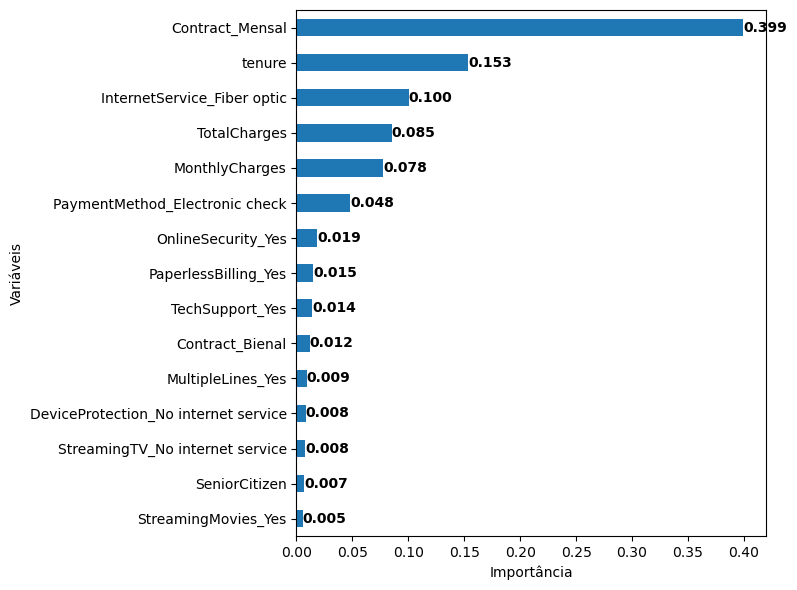

In [41]:
# Selecionando as 15 variáveis mais importantes
top_features = feature_importances.head(15).sort_values()

# Criando o gráfico
ax = top_features.plot(
    kind="barh",
    figsize=(8,6)
)

# Inserindo os valores nas barras
for i, v in enumerate(top_features.values):
    ax.text(
        v,
        i,
        f"{v:.3f}",
        va="center",
        fontweight="bold"
    )

plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

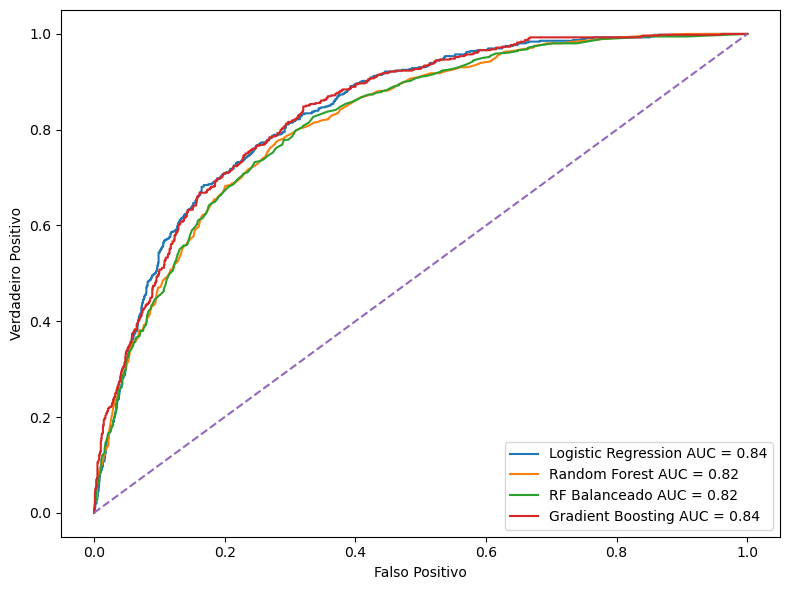

In [ ]:
# Curva ROC comparando modelos

# Probabilidades dos modelos
y_prob_lr = modelo_baseline.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:,1]
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

# Cálculo das curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_rf_bal, tpr_rf_bal, _ = roc_curve(y_test, y_prob_rf_bal)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression AUC = {roc_auc_score(y_test, y_prob_lr):.2f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.2f}")
plt.plot(fpr_rf_bal, tpr_rf_bal, label=f"RF Balanceado AUC = {roc_auc_score(y_test, y_prob_rf_bal):.2f}")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting AUC = {roc_auc_score(y_test, y_prob_gb):.2f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.tight_layout()

plt.legend(loc="lower right")
plt.show()

In [ ]:
## Extraindo as métricas de cada modelo para comparação

# Gradient Boosting
acc_gb = accuracy_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

# Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Random Forest Balanceado
acc_rf_bal = accuracy_score(y_test, y_pred_rf_balanced)
rec_rf_bal = recall_score(y_test, y_pred_rf_balanced)
f1_rf_bal = f1_score(y_test, y_pred_rf_balanced)

# Logistic Regression
acc_log = accuracy_score(y_test, y_pred_lr)
rec_log = recall_score(y_test, y_pred_lr)
f1_log = f1_score(y_test, y_pred_lr)

In [44]:
# Comparando os modelos em um DataFrame
resultados_modelos = pd.DataFrame({
    "Modelo":[
        "Regressão Logística",
        "Random Forest",
        "Random Forest Balanceado",
        "Gradient Boosting"
    ],
    "Accuracy":[
        acc_log,
        acc_rf,
        acc_rf_bal,
        acc_gb
    ],
    "Recall_Churn":[
        rec_log,
        rec_rf,
        rec_rf_bal,
        rec_gb
    ],
    "F1_Churn":[
        f1_log,
        f1_rf,
        f1_rf_bal,
        f1_gb
    ]
})

resultados_modelos

,Modelo,Accuracy,Recall_Churn,F1_Churn
0,Regressão Logística,0.806161,0.566845,0.608612
1,Random Forest,0.784834,0.474153,0.539554
2,Random Forest Balanceado,0.778673,0.461676,0.525888
3,Gradient Boosting,0.793839,0.508021,0.567164


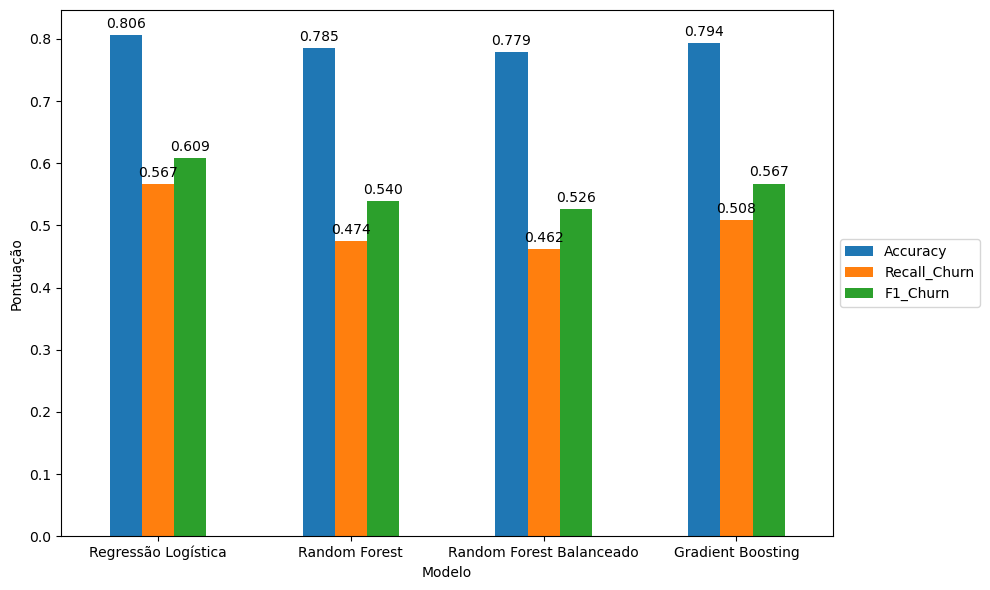

In [45]:
# Transformando o DataFrame em um gráfico
ax = resultados_modelos.set_index("Modelo")[["Accuracy", "Recall_Churn", "F1_Churn"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Pontuação")
plt.xticks(rotation=0)

# Inserindo valores nas barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()